# SMARTSPEND: AI-Powered Financial Behavior Prediction

## Problem Statement
This notebook demonstrates a research-oriented and classroom-friendly pipeline to predict financial behavior outcomes from transaction data.

**Goals:**
- Build reproducible ML workflows
- Showcase live model training simulation
- Produce academic outputs (metrics tables, plots, model artifacts)

In [1]:
# Core imports
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
import joblib

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
pd.options.mode.copy_on_write = False

def to_writable(x):
    return np.asarray(x).copy()

OUT_DIR = "D:/newwork/finset/outputs"
os.makedirs(OUT_DIR, exist_ok=True)

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_context("talk", font_scale=0.8)
print("Environment ready. Output folder:", os.path.abspath(OUT_DIR))

Environment ready. Output folder: D:\newwork\finset\outputs


## Data Analysis
Load transaction CSV and inspect quality.

Expected columns (flexible):
- `user_id`, `date`, `amount`, `category`, `type` (debit/credit)
- optional target: `target`

If target is missing, this notebook creates a demo target based on risk heuristics.

In [2]:
DATA_PATH = "D:/newwork/finset/data/transactions.csv"

if not os.path.exists(DATA_PATH):
    print(f"Dataset not found at {DATA_PATH}. Generating demo dataset for live classroom run...")
    n = 1200
    dates = pd.date_range("2025-01-01", periods=n, freq="D")
    demo = pd.DataFrame({
        "user_id": np.random.randint(1, 80, size=n),
        "date": np.random.choice(dates, size=n),
        "amount": np.round(np.random.gamma(shape=2.0, scale=1200, size=n), 2),
        "category": np.random.choice(["Food", "Rent", "Utilities", "Shopping", "Transport", "EMI", "Subscription"], size=n),
        "type": np.random.choice(["debit", "credit"], size=n, p=[0.75, 0.25])
    })
    os.makedirs("D:/newwork/finset/data", exist_ok=True)
    demo.to_csv(DATA_PATH, index=False)
    print("Demo data created:", DATA_PATH)

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
display(df.head())
display(df.isna().sum())

Shape: (1200, 5)


,user_id,date,amount,category,type
0,52,2025-03-14,856.17,Utilities,debit
1,15,2026-12-14,856.57,Food,debit
2,72,2025-10-23,758.76,Rent,debit
3,61,2027-11-07,249.99,Rent,debit
4,21,2025-03-02,2281.71,Food,debit


user_id     0
date        0
amount      0
category    0
type        0
dtype: int64

## Feature Engineering
Features added:
- Monthly spending per user
- Category frequency per user
- Weekend vs weekday spending flag
- Basic anomaly indicator using z-score on amount
- Expense/Income ratio per user
- Transaction count per user

In [3]:
# Ensure required columns exist
required = ["user_id", "date", "amount", "category", "type"]
missing_required = [c for c in required if c not in df.columns]
if missing_required:
    raise ValueError(f"Dataset missing required columns: {missing_required}")

# Parse dates
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Missing-value handling (raw table stage)
df["category"] = df["category"].fillna("Unknown")
df["type"] = df["type"].fillna("debit")
df["amount"] = pd.to_numeric(df["amount"], errors="coerce")
df["amount"] = df["amount"].fillna(df["amount"].median())
df = df.dropna(subset=["date"]).copy()

# Calendar features
df["month"] = df["date"].dt.to_period("M").astype(str)
df["day_of_week"] = df["date"].dt.day_name()
df["is_weekend"] = df["date"].dt.dayofweek.isin([5, 6]).astype(int)

# Monthly spend per user (debit only)
monthly_spend = (
    df[df["type"].str.lower() == "debit"]
    .groupby(["user_id", "month"]) ["amount"]
    .sum()
    .reset_index(name="monthly_spend")
)
monthly_spend_user = monthly_spend.groupby("user_id") ["monthly_spend"].mean().rename("monthly_spend_user")

# Category frequency per user
cat_freq = (
    df.groupby(["user_id", "category"]).size().reset_index(name="cnt")
)
top_cat_freq_user = cat_freq.groupby("user_id")["cnt"].max().rename("top_category_frequency")

# Basic anomaly indicator: amount z-score > 2
amount_mean = df["amount"].mean()
amount_std = df["amount"].std() + 1e-6
df["anomaly_indicator"] = (((df["amount"] - amount_mean) / amount_std).abs() > 2).astype(int)

# Aggregated user-level table
agg = df.groupby("user_id").agg(
    total_transactions=("amount", "count"),
    avg_amount=("amount", "mean"),
    total_amount=("amount", "sum"),
    weekend_ratio=("is_weekend", "mean"),
    anomaly_count=("anomaly_indicator", "sum"),
).reset_index()

income = df[df["type"].str.lower() == "credit"].groupby("user_id")["amount"].sum().rename("total_income")
expense = df[df["type"].str.lower() == "debit"].groupby("user_id")["amount"].sum().rename("total_expense")

features = agg.merge(income, on="user_id", how="left").merge(expense, on="user_id", how="left")
features = features.merge(monthly_spend_user, on="user_id", how="left")
features = features.merge(top_cat_freq_user, on="user_id", how="left")

features["total_income"] = features["total_income"].fillna(0)
features["total_expense"] = features["total_expense"].fillna(0)
features["expense_income_ratio"] = features["total_expense"] / (features["total_income"] + 1e-6)

# Dominant category per user (categorical feature)
dominant_category = (
    df.groupby(["user_id", "category"]).size()
      .reset_index(name="cnt")
      .sort_values(["user_id", "cnt"], ascending=[True, False])
      .drop_duplicates("user_id")[["user_id", "category"]]
      .rename(columns={"category": "dominant_category"})
)
features = features.merge(dominant_category, on="user_id", how="left")

# Create/attach target
if "target" in df.columns:
    # If target exists transaction-level, aggregate with mode per user
    target_user = df.groupby("user_id")["target"].agg(lambda s: s.mode().iloc[0] if not s.mode().empty else s.iloc[0]).rename("target")
    features = features.merge(target_user, on="user_id", how="left")
else:
    # Heuristic demo target: 1 = risky behavior, 0 = stable
    features["target"] = (
        (features["expense_income_ratio"] > 0.9)
        | (features["anomaly_count"] >= 3)
        | (features["weekend_ratio"] > 0.45)
    ).astype(int)

features = features.fillna({
    "monthly_spend_user": features["monthly_spend_user"].median(),
    "top_category_frequency": features["top_category_frequency"].median(),
    "dominant_category": "Unknown"
})

print("Feature table shape:", features.shape)
display(features.head())

Feature table shape: (79, 13)


,user_id,total_transactions,avg_amount,total_amount,weekend_ratio,anomaly_count,total_income,total_expense,monthly_spend_user,top_category_frequency,expense_income_ratio,dominant_category,target
0,1,24,2322.248750,55733.97,0.333333,1,26843.78,28890.19,2063.585000,6,1.076234,Subscription,1
1,2,20,2361.407000,47228.14,0.250000,1,10903.19,36324.95,3302.268182,6,3.331589,Food,1
2,3,15,2093.778667,31406.68,0.333333,1,7682.14,23724.54,2636.060000,5,3.088272,Utilities,1
3,4,16,2220.559375,35528.95,0.125000,0,10781.52,24747.43,2062.285833,5,2.295356,Subscription,1
4,5,18,2998.531111,53973.56,0.277778,1,3611.81,50361.75,3357.450000,3,13.943632,EMI,1


## Model Training
Train/test split with reproducibility and preprocessing pipeline:
- Missing-value imputation
- Numerical scaling
- Categorical encoding

Models:
1. RandomForestClassifier
2. LogisticRegression

In [4]:
target_col = "target"
drop_cols = ["user_id", target_col]

X = features.drop(columns=drop_cols)
y = features[target_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

num_cols = X.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

numeric_preprocess = Pipeline(steps=[
    ("to_writable", FunctionTransformer(to_writable, validate=False)),
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_preprocess = Pipeline(steps=[
    ("to_writable", FunctionTransformer(to_writable, validate=False)),
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocess, num_cols),
        ("cat", categorical_preprocess, cat_cols),
    ]
)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Train shape: (63, 11) | Test shape: (16, 11)
Numerical columns: ['total_transactions', 'avg_amount', 'total_amount', 'weekend_ratio', 'anomaly_count', 'total_income', 'total_expense', 'monthly_spend_user', 'top_category_frequency', 'expense_income_ratio']
Categorical columns: ['dominant_category']


## Live Training Simulation
Iteratively train RandomForest with increasing complexity and update plots in real-time.

[RF Iter 1] n_estimators=20 | Acc=1.0000 | Prec=1.0000 | Recall=1.0000 | F1=1.0000


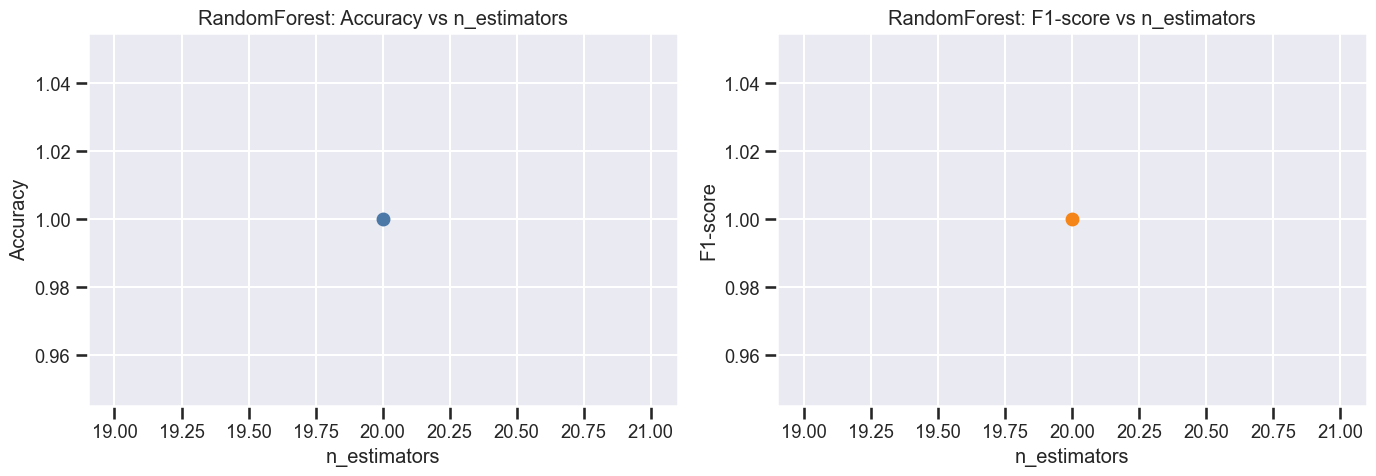

[RF Iter 2] n_estimators=50 | Acc=1.0000 | Prec=1.0000 | Recall=1.0000 | F1=1.0000


<Figure size 640x480 with 0 Axes>

[RF Iter 3] n_estimators=100 | Acc=1.0000 | Prec=1.0000 | Recall=1.0000 | F1=1.0000


<Figure size 640x480 with 0 Axes>

[RF Iter 4] n_estimators=150 | Acc=1.0000 | Prec=1.0000 | Recall=1.0000 | F1=1.0000


<Figure size 640x480 with 0 Axes>

[RF Iter 5] n_estimators=220 | Acc=1.0000 | Prec=1.0000 | Recall=1.0000 | F1=1.0000


<Figure size 640x480 with 0 Axes>

Best RF n_estimators: 20


In [5]:
rf_iterations = [20, 50, 100, 150, 220]
rf_live_results = []

plt.ion()
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

for i, n_trees in enumerate(rf_iterations, 1):
    rf_model = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", RandomForestClassifier(n_estimators=n_trees, random_state=SEED, n_jobs=-1, class_weight="balanced"))
    ])
    rf_model.fit(X_train, y_train)
    preds = rf_model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)

    rf_live_results.append({
        "model": "RandomForest",
        "iteration": i,
        "complexity": n_trees,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1,
    })

    print(f"[RF Iter {i}] n_estimators={n_trees} | Acc={acc:.4f} | Prec={prec:.4f} | Recall={rec:.4f} | F1={f1:.4f}")

    hist = pd.DataFrame(rf_live_results)
    ax[0].cla(); ax[1].cla()
    ax[0].plot(hist["complexity"], hist["accuracy"], marker="o", color="#4c78a8")
    ax[1].plot(hist["complexity"], hist["f1_score"], marker="o", color="#f58518")
    ax[0].set_title("RandomForest: Accuracy vs n_estimators")
    ax[1].set_title("RandomForest: F1-score vs n_estimators")
    ax[0].set_xlabel("n_estimators"); ax[1].set_xlabel("n_estimators")
    ax[0].set_ylabel("Accuracy"); ax[1].set_ylabel("F1-score")
    plt.tight_layout()
    plt.pause(0.35)
    time.sleep(0.35)

plt.ioff()
plt.show()

# Best RF from iterative run
rf_best_row = pd.DataFrame(rf_live_results).sort_values("f1_score", ascending=False).iloc[0]
best_rf_trees = int(rf_best_row["complexity"])
print("Best RF n_estimators:", best_rf_trees)

## Final Model Fitting (RandomForest + LogisticRegression)

In [6]:
# Final RF
rf_final = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=best_rf_trees,
        random_state=SEED,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

# Logistic Regression
log_final = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        random_state=SEED,
        max_iter=800,
        class_weight="balanced"
    ))
])

rf_final.fit(X_train, y_train)
log_final.fit(X_train, y_train)

rf_pred = rf_final.predict(X_test)
log_pred = log_final.predict(X_test)

## Evaluation
Compute Accuracy, Precision, Recall, F1-score, classification report, and confusion matrix.

In [7]:
def eval_model(name, y_true, y_pred):
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
    }

rf_metrics = eval_model("RandomForest", y_test, rf_pred)
log_metrics = eval_model("LogisticRegression", y_test, log_pred)

metrics_df = pd.DataFrame([rf_metrics, log_metrics]).sort_values("f1_score", ascending=False)
display(metrics_df)

print("\
Classification Report - RandomForest")
print(classification_report(y_test, rf_pred, zero_division=0))

print("Classification Report - LogisticRegression")
print(classification_report(y_test, log_pred, zero_division=0))

,model,accuracy,precision,recall,f1_score
0,RandomForest,1.0,1.0,1.0,1.0
1,LogisticRegression,1.0,1.0,1.0,1.0


Classification Report - RandomForest
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        16

    accuracy                           1.00        16
   macro avg       1.00      1.00      1.00        16
weighted avg       1.00      1.00      1.00        16

Classification Report - LogisticRegression
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        16

    accuracy                           1.00        16
   macro avg       1.00      1.00      1.00        16
weighted avg       1.00      1.00      1.00        16



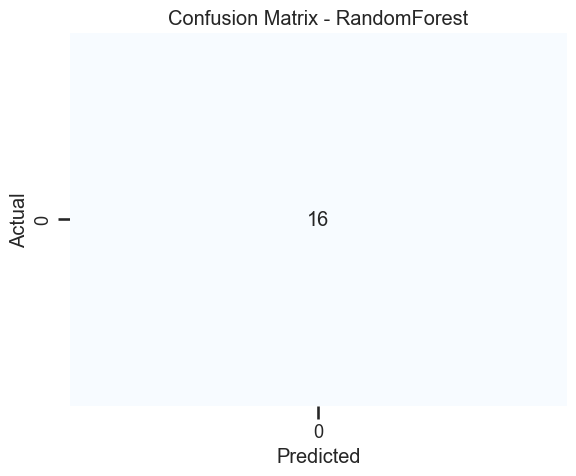

Saved: D:/newwork/finset/outputs\confusion_matrix.png


In [8]:
# Confusion matrix for best model
best_model_name = metrics_df.iloc[0]["model"]
best_pred = rf_pred if best_model_name == "RandomForest" else log_pred

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
cm_path = os.path.join(OUT_DIR, "confusion_matrix.png")
plt.savefig(cm_path, dpi=160)
plt.show()
print("Saved:", cm_path)

## Live Visualization Summary
Save dynamic training graph and model metrics for report usage.

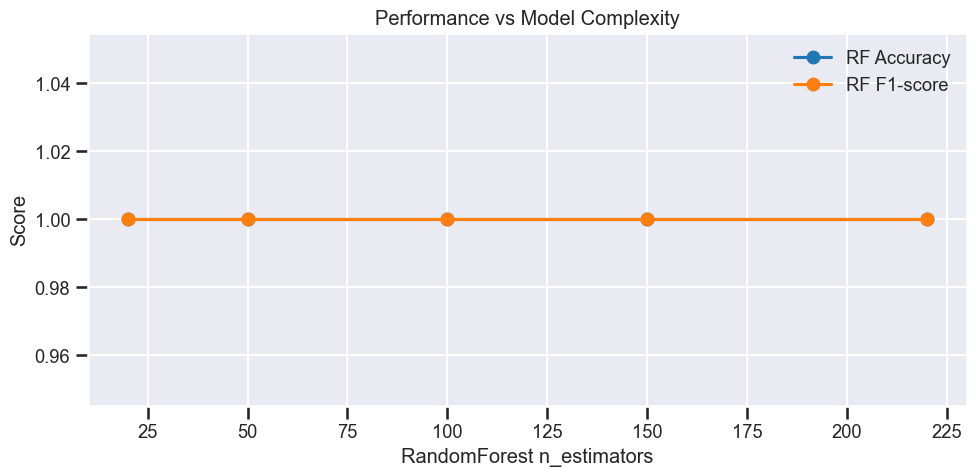

Saved: D:/newwork/finset/outputs\performance_graph.png


In [9]:
rf_hist_df = pd.DataFrame(rf_live_results)

plt.figure(figsize=(10, 5))
plt.plot(rf_hist_df["complexity"], rf_hist_df["accuracy"], marker="o", label="RF Accuracy")
plt.plot(rf_hist_df["complexity"], rf_hist_df["f1_score"], marker="o", label="RF F1-score")
plt.title("Performance vs Model Complexity")
plt.xlabel("RandomForest n_estimators")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
perf_path = os.path.join(OUT_DIR, "performance_graph.png")
plt.savefig(perf_path, dpi=160)
plt.show()
print("Saved:", perf_path)

## Research Outputs
Save:
- `metrics.csv`
- `predictions.csv`
- `model_v1.pkl`

In [10]:
metrics_csv = os.path.join(OUT_DIR, "metrics.csv")
metrics_df.to_csv(metrics_csv, index=False)

predictions_df = X_test.copy()
predictions_df["y_true"] = y_test.values
predictions_df["rf_pred"] = rf_pred
predictions_df["log_pred"] = log_pred
predictions_df["best_pred"] = best_pred
pred_csv = os.path.join(OUT_DIR, "predictions.csv")
predictions_df.to_csv(pred_csv, index=False)

best_model = rf_final if best_model_name == "RandomForest" else log_final
model_path = os.path.join(OUT_DIR, "model_v1.pkl")
joblib.dump(best_model, model_path)

print("Saved files:")
print("-", metrics_csv)
print("-", pred_csv)
print("-", model_path)

Saved files:
- D:/newwork/finset/outputs\metrics.csv
- D:/newwork/finset/outputs\predictions.csv
- D:/newwork/finset/outputs\model_v1.pkl


## Model Comparison & Conclusion

### How the models work
- **RandomForest**: ensemble of decision trees; handles nonlinear interactions and feature mix well.
- **LogisticRegression**: linear baseline; interpretable and fast for benchmark comparison.

### Why this is suitable for financial prediction
- Captures behavior from spending intensity, weekend tendency, anomalies, and category patterns.
- Provides robust baseline + nonlinear model comparison.
- Generates reproducible, report-ready artifacts for classroom/research demonstration.

### Final selection criterion
Best model selected by highest **F1-score**, balancing precision and recall for risk-sensitive use cases.

In [11]:
best_row = metrics_df.iloc[0]
print("Best Model:", best_row["model"])
print(f"Accuracy : {best_row['accuracy']:.4f}")
print(f"Precision: {best_row['precision']:.4f}")
print(f"Recall   : {best_row['recall']:.4f}")
print(f"F1-score : {best_row['f1_score']:.4f}")
print("\
Notebook run complete. Outputs available in:", os.path.abspath(OUT_DIR))

Best Model: RandomForest
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000
Notebook run complete. Outputs available in: D:\newwork\finset\outputs
